In [1]:
import random
import numpy as np
random_seed = 70001
random.seed(random_seed)
np.random.seed(random_seed)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics, svm
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
# Loading the data
df = pd.read_csv("digitraffic_weather_balanced_ver1_2025.csv")

In [3]:
# See the first 5 rows of the data
df.head()

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature,condition
0,-12.700000,5.500000,47.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.820000,487.00000,-8.800000,Normal
1,-5.410822,3.258918,92.627857,1.519791,4.102134,0.0,0.030638,0.342042,0.000000,0.353418,210.62993,-2.769641,Ice
2,-3.200000,2.100000,96.000000,4.000000,2.100000,0.0,0.000000,0.340000,0.110000,0.380000,112.00000,-8.100000,Snow
3,0.400000,0.900000,98.000000,0.000000,0.700000,0.0,0.020000,0.000000,0.000000,0.820000,465.00000,4.550000,Rain
4,-6.922236,2.760301,76.322821,2.726796,3.085823,0.0,0.154453,0.220241,0.002743,0.367550,105.00000,-1.300000,Ice


In [4]:
# Check for duplicates
df.duplicated().sum()

np.int64(36)

In [5]:
# Drop duplicates
df = df.drop_duplicates()

In [6]:
# Lets see howmany weather conditions are there
df['condition'].value_counts()

condition
Rain      595
Normal    570
Snow      511
Ice       415
Name: count, dtype: int64

In [7]:
# check for missing values
df.isna().sum()

dew_point           0
avg_wind            0
humidity            0
rain                0
rain_sum            0
snow_depth          0
rain_amount         0
snow_amount         0
ice_measure         0
friction            0
ice_frequency       0
mean_temperature    0
condition           0
dtype: int64

In [8]:
# Mapping the weather conditions to numbers. Then we can use this for classification.
# Ice: 0, Normal: 1, Rain: 2, Snow: 3
# Further saving the labels to a list for later use
mapping = {"Ice": 0, "Normal": 1, "Rain": 2, "Snow": 3}
df['condition'] = df['condition'].map(mapping)
labels = ["Ice", "Normal", "Rain", "Snow"]

In [9]:
# Hesding of the data
df.head()

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature,condition
0,-12.700000,5.500000,47.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.820000,487.00000,-8.800000,1
1,-5.410822,3.258918,92.627857,1.519791,4.102134,0.0,0.030638,0.342042,0.000000,0.353418,210.62993,-2.769641,0
2,-3.200000,2.100000,96.000000,4.000000,2.100000,0.0,0.000000,0.340000,0.110000,0.380000,112.00000,-8.100000,3
3,0.400000,0.900000,98.000000,0.000000,0.700000,0.0,0.020000,0.000000,0.000000,0.820000,465.00000,4.550000,2
4,-6.922236,2.760301,76.322821,2.726796,3.085823,0.0,0.154453,0.220241,0.002743,0.367550,105.00000,-1.300000,0


In [10]:
# Splitting the data into features and target variable
X = df.drop("condition", axis=1)

# Set the target variable
y = df['condition']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [12]:
# Random Forest Classifier
# estimators in a Random Forest are the collection of decision trees used for making predictions. we use 200 trees
# Each decision tree in the random forest can grow up to a depth of 25.
model = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=220, max_depth=28))
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=28, n_estimators=220))])

In [13]:
# Predicting the test set results
predictions = model.predict(X_test)

In [14]:
# Classifications report
print(classification_report(y_test, predictions, target_names=labels))

# Overall accuracy
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

         Ice       0.99      0.99      0.99        89
      Normal       0.94      0.95      0.94       117
        Rain       0.92      0.91      0.92       105
        Snow       0.97      0.97      0.97       108

    accuracy                           0.95       419
   macro avg       0.96      0.96      0.96       419
weighted avg       0.95      0.95      0.95       419


Model overall accuracy: 95.47%


## Great we have more than 95% Accuracy 

[[ 88   0   0   1]
 [  0 111   5   1]
 [  1   7  96   1]
 [  0   0   3 105]]


<Axes: >

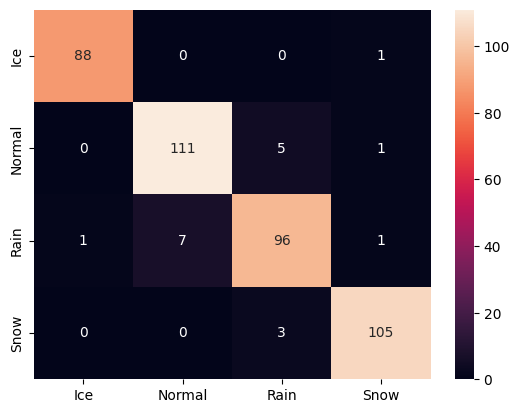

In [15]:
# Plotting the confusion matrix
print(confusion_matrix(y_test, predictions))

sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g', xticklabels=labels, yticklabels=labels)

In [16]:
# Save the model
from joblib import dump
dump(model, "weather_decision_model.joblib")

['weather_decision_model.joblib']